In [164]:
# Import
# !pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv('../data/rpgg_db_1903.csv')
df.head()

,rank,names,geek rating,avg rating,num votes,year,thumb_url
0,1,The Great Pendragon Campaign,8.296,9.00,118,2006.0,http:https://cf.geekdo-images.com/micro/img/eg...
1,2,Delta Green,8.213,8.58,243,1996.0,http:https://cf.geekdo-images.com/micro/img/G0...
2,3,Masks of Nyarlathotep (3rd & 4th edition),8.173,8.54,214,1996.0,http:https://cf.geekdo-images.com/micro/img/NG...
3,4,Player's Handbook (D&D 5e),8.163,8.48,578,2014.0,http:https://cf.geekdo-images.com/micro/img/-b...
4,5,Countdown,8.145,8.73,124,1999.0,http:https://cf.geekdo-images.com/micro/img/OD...


In [165]:
# Test for high cardinality
print(df.shape)
print(df.nunique())
# rank, names, and thumb_url are all high cardinality

(5000, 7)
rank           5000
names          4952
geek rating    1198
avg rating      316
num votes       203
year             45
thumb_url      4984
dtype: int64


<Axes: ylabel='Frequency'>

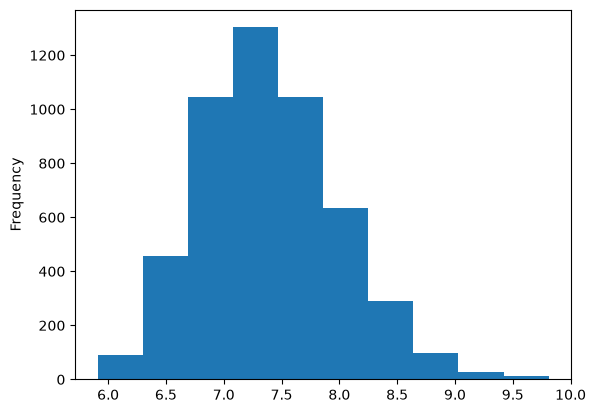

In [166]:
# Plot output feature to visualize
df['avg rating'].plot(kind='hist')

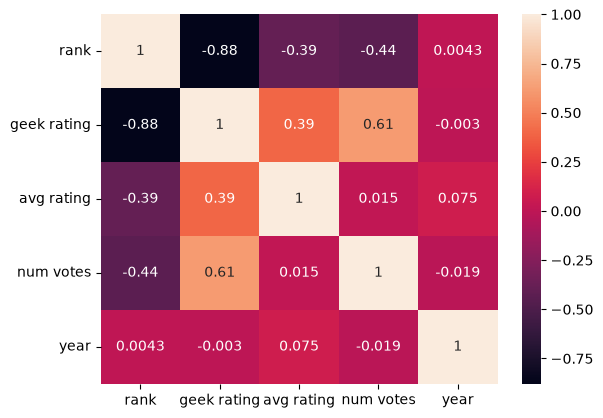

In [167]:
# see correlation plot to see relationship to other features
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

In [168]:
# split into input/output
X = df[['num votes', 'year']]
y = df['avg rating']

# Create DummyRegresser, fit and score
from sklearn.dummy import DummyRegressor
dr = DummyRegressor()
dr.fit(X,y)
print(dr.predict([[496, 2004]]))
print(dr.score(X,y))

[7.39451]
0.0


In [169]:
# New Feature - name length
df['name_length'] = df['names'].str.len()
# reset input features
X = df[['num votes', 'year', 'name_length']]
# refit, predict, and score
dr.fit(X,y)
print(dr.predict([[496, 2004]]))
print(dr.score(X,y))

[7.39451]
0.0


In [170]:
# check input features types and look for NaN
print(X.dtypes)
print(df['year'].isna().sum())

num votes        int64
year           float64
name_length      int64
dtype: object
16


In [171]:
# split into input/output
X = df[['num votes', 'year']]
y = df['avg rating']

# Create DummyRegresser, fit and score
from sklearn.dummy import DummyRegressor
dr = DummyRegressor()
dr.fit(X,y)
print(dr.predict([[496, 2004]]))
print(dr.score(X,y))

[7.39451]
0.0


In [172]:
# New Feature - name length
df['name_length'] = df['names'].str.len()
# reset input features
X = df[['num votes', 'year', 'name_length']]
# refit, predict, and score
dr.fit(X,y)
print(dr.predict([[496, 2004]]))
print(dr.score(X,y))

[7.39451]
0.0


In [173]:
# check input features types and look for NaN
print(X.dtypes)
print(df['num votes'].isna().sum())
print(df['year'].isna().sum())
print(df['name_length'].isna().sum())

num votes        int64
year           float64
name_length      int64
dtype: object
0
16
0


<Axes: ylabel='Frequency'>

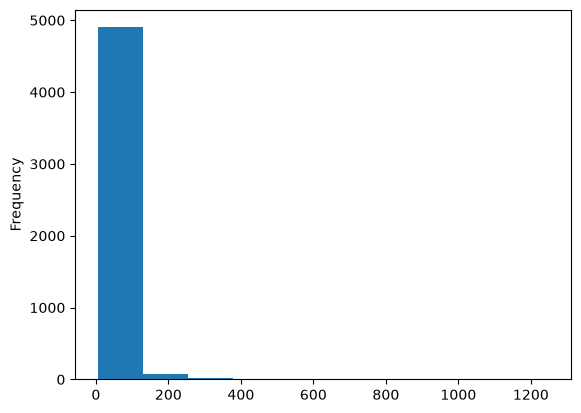

In [174]:
# visualize input features
df['num votes'].plot(kind='hist')

<Axes: ylabel='Frequency'>

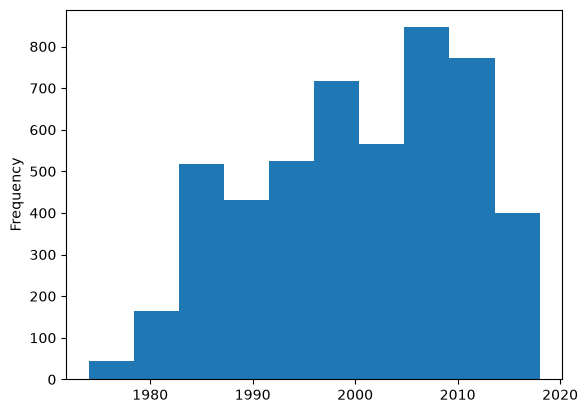

In [175]:
df['year'].plot(kind='hist')

<Axes: ylabel='Frequency'>

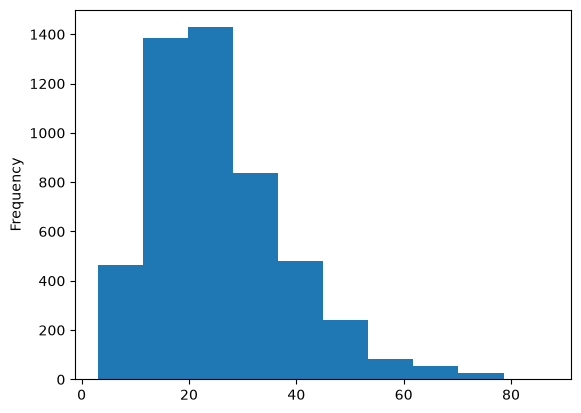

In [176]:
df['name_length'].plot(kind='hist')

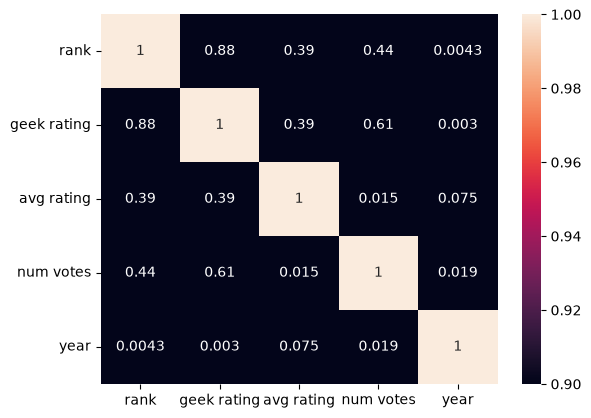

In [177]:
# Check colinearity
corr = corr.abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.show()

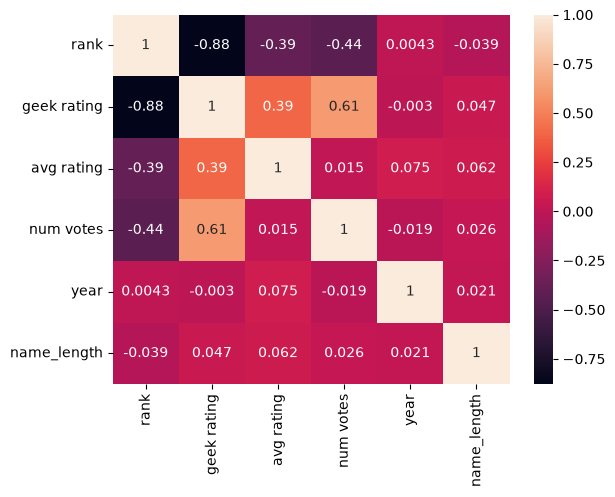

In [178]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()